<a href="https://colab.research.google.com/github/31251026017/homeworkAI-23.1-23.15/blob/main/NhandienLT0001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/SELFIE"

# Kích thước ảnh và kích thước lô
img_width, img_height = 200, 200
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255,           # Normalize giá trị pixel về [0, 1]
    rotation_range=30,         # Xoay ảnh ngẫu nhiên trong khoảng 30 độ
    width_shift_range=0.2,     # Dịch chuyển ảnh ngang 20%
    height_shift_range=0.2,    # Dịch chuyển ảnh dọc 20%
    shear_range=0.2,           # Cắt nghiêng ảnh 20%
    zoom_range=0.2,            # Phóng to/thu nhỏ ảnh 20%
    horizontal_flip=True,      # Lật ngang ảnh ngẫu nhiên
    fill_mode="nearest"        # Cách lấp đầy pixel mới sau khi biến đổi
)

In [4]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),  # Giảm overfitting
    Dense(34, activation="softmax")  # 5 categories (lớp đầu ra)
])

Found 2029 images belonging to 34 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,764,898 (33.44 MB)

 Trainable params: 8,764,898 (33.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 463ms/step - accuracy: 0.7831 - loss: 0.7938
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 442ms/step - accuracy: 0.8137 - loss: 0.6808
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 439ms/step - accuracy: 0.8098 - loss: 0.6812
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 435ms/step - accuracy: 0.7989 - loss: 0.7206
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 439ms/step - accuracy: 0.8275 - loss: 0.5988
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 432ms/step - accuracy: 0.8245 - loss: 0.6053
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 436ms/step - accuracy: 0.8275 - loss: 0.5921
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 437ms/step - accuracy: 0.8359 - loss: 0.5689
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 440ms/step - accuracy: 0.8457 - loss: 0.5354
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 435ms/step - accuracy: 0.8556 - loss: 0.5075
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 438ms/step - accuracy: 0.8561 - loss: 0.4959
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28

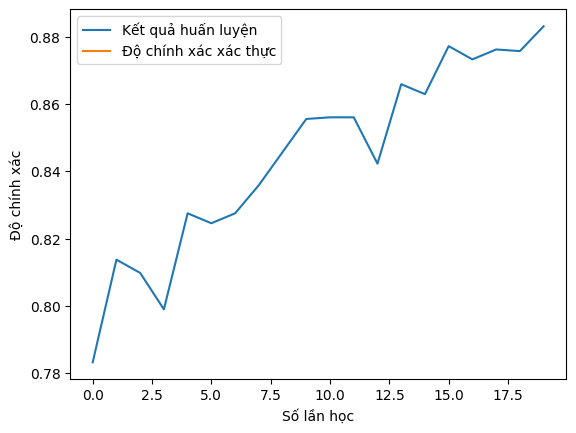

In [13]:
# Biên dịch mô hình
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
epochs = 20
history = model.fit(train_generator, epochs=epochs)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
# Lưu ý: Chỉ vẽ 'val_accuracy' nếu bạn có cung cấp validation_data trong model.fit
plt.plot(history.history.get('val_accuracy', []), label="Độ chính xác xác thực")

plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [14]:
model.save("/content/LT0001.keras")

Saving khanh.jpg to khanh (1).jpg


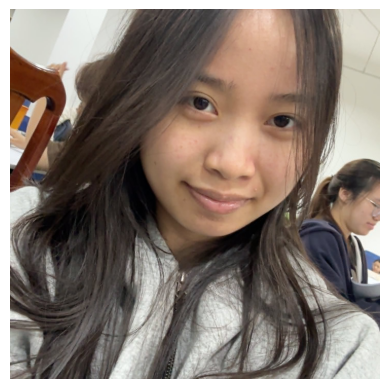

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
Prediction: [[4.34240101e-05 7.33773708e-10 1.36800751e-01 4.79331064e-09
  5.11538110e-06 3.90194464e-06 1.97926965e-06 1.22166603e-06
  8.14469755e-01 2.02009236e-04 5.69867931e-10 1.91017948e-11
  1.34342454e-05 7.26045779e-10 2.33010326e-07 4.20184820e-09
  3.06760271e-08 3.44676619e-06 1.02262024e-03 1.61568718e-15
  5.97155235e-07 5.30125388e-11 1.09440401e-10 1.75729848e-03
  3.72093645e-08 5.83543697e-05 1.57853890e-07 2.33330312e-07
  1.00513404e-07 2.95394529e-02 1.57131967e-06 7.58505557e-05
  1.59984026e-02 3.96128026e-11]]
Kết quả: Lê Ngọc Quỳnh Khanh
Kết quả: Lê Ngọc Quỳnh Khanh
Độ chính xác: 81.45%


In [24]:
from keras.models import load_model
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = load_model("/content/LT0001.keras")

# Danh sách class
classes = list(train_generator.class_indices.keys())

# Upload ảnh
uploaded = files.upload()

# Lấy tên file
img_path = list(uploaded.keys())[0]

# Đọc ảnh
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Hiển thị ảnh
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# Resize đúng kích thước model
img_resize = cv2.resize(img_rgb, (200, 200))

# Normalize
img_resize = img_resize.astype('float32') / 255.0

# Thêm chiều batch
img_input = np.expand_dims(img_resize, axis=0)

# Predict
prediction = model.predict(img_input)

# Lấy class
predicted_class = np.argmax(prediction)

# In kết quả
print("Prediction:", prediction)
print("Kết quả:", classes[predicted_class])

confidence = np.max(prediction) * 100
print(f"Kết quả: {classes[predicted_class]}")
print(f"Độ chính xác: {confidence:.2f}%")